# Elevator 2D vs Elevator 3D Diagnostics

This notebook compares rollouts:
- 2D elevator: `rollout_terms_stage_0_16_full_test1_2d.csv`
- 3D elevator: `rollout_terms_stage_0_16_full_test3_2dwing_3delev.csv`

It detects the first divergence stage and visualizes elevator-related terms.

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import yaml

plt.style.use('seaborn-v0_8-whitegrid')

def find_workspace_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur, *cur.parents]:
        if (p / 'diagnostics').exists() and (p / 'glider_optimization').exists():
            return p
    return cur

root = find_workspace_root(Path.cwd())
diag = root / 'diagnostics/2026-02-13_3d-llt-debug'
f2 = diag / 'rollout_terms_stage_0_16_full_test1_2d.csv'
f3 = diag / 'rollout_terms_stage_0_16_full_test3_2dwing_3delev.csv'
print('Root:', root)
print('2D CSV exists:', f2.exists(), f2)
print('3D CSV exists:', f3.exists(), f3)

assert f2.exists(), f'Missing file: {f2}'
assert f3.exists(), f'Missing file: {f3}'

Root: /Users/gherardi/Documents/GitHub/glider_optimization_debug
2D CSV exists: True /Users/gherardi/Documents/GitHub/glider_optimization_debug/diagnostics/2026-02-13_3d-llt-debug/rollout_terms_stage_0_16_full_test1_2d.csv
3D CSV exists: True /Users/gherardi/Documents/GitHub/glider_optimization_debug/diagnostics/2026-02-13_3d-llt-debug/rollout_terms_stage_0_16_full_test3_2dwing_3delev.csv


In [75]:
df2 = pd.read_csv(f2)
df3 = pd.read_csv(f3)

if 'stage' not in df2.columns or 'stage' not in df3.columns:
    raise ValueError('Both CSVs must contain a stage column.')

common = sorted(set(df2.columns).intersection(df3.columns))
df2 = df2[common].copy()
df3 = df3[common].copy()
df = df2.merge(df3, on='stage', suffixes=('_2d', '_3d')).sort_values('stage')

print('Rows:', len(df), '| Common columns:', len(common))
print('Example columns:', common[:20])
df.head()

Rows: 17 | Common columns: 42
Example columns: ['CD_e', 'CD_w', 'CL_e', 'CL_w', 'CM_e', 'CM_w', 'F_ex', 'F_ez', 'F_wx', 'F_wz', 'M_e', 'M_w', 'Re', 'Re_e', 'alpha_e', 'alpha_w', 'phi', 'q_e', 'r_e_x', 'r_e_z']


,CD_e_2d,CD_w_2d,CL_e_2d,CL_w_2d,CM_e_2d,CM_w_2d,F_ex_2d,F_ez_2d,F_wx_2d,F_wz_2d,...,x_3d,x_edot_3d,x_wdot_3d,xddot_3d,xdot_3d,z_3d,z_edot_3d,z_wdot_3d,zddot_3d,zdot_3d
0,0.400000,0.303614,-0.800000,-0.806010,0.200000,0.097383,2.793966e-08,-0.419095,0.387138,-3.730811,...,-8.500000,6.000000,6.000000,6.787190,6.000000,0.000000,3.000000,3.000000,-74.140813,3.000000
1,0.157617,0.218021,-0.538880,-0.532723,0.134720,0.026476,1.036157e-08,-0.233026,-0.066403,-2.334263,...,-8.440000,6.067872,6.067872,-0.739738,6.067872,0.030000,2.966269,2.218490,-50.946392,2.258592
2,0.045243,0.168410,-0.297386,-0.338691,0.074346,-0.009616,2.077259e-03,-0.118425,-0.250454,-1.435843,...,-8.379321,6.098317,6.058330,-3.522693,6.060475,0.052586,3.353048,1.658239,-42.811470,1.749128
3,0.005844,0.126436,-0.107955,-0.180005,0.026989,-0.032755,1.826070e-03,-0.041535,-0.297193,-0.758284,...,-8.318717,6.241596,6.012988,-6.517860,6.025248,0.070077,4.122693,1.162251,-40.690447,1.321013
4,0.000370,0.098488,0.027215,-0.068401,-0.006804,-0.043894,-7.633099e-04,0.010309,-0.296138,-0.312587,...,-8.258464,6.733917,5.916218,-10.127238,5.960069,0.083287,5.402421,0.659771,-47.795039,0.914109


In [76]:
# Divergence detection
def g(r, name, sfx):
    k = f'{name}_{sfx}'
    return r[k] if k in r.index else np.nan

thr_thetadot = 5.0
thr_tau_ratio = 3.0
eps = 1e-9

div_stage = None
reasons = []
for _, r in df.iterrows():
    td2 = g(r, 'thetadot', '2d')
    td3 = g(r, 'thetadot', '3d')
    te2 = g(r, 'tau_e', '2d')
    te3 = g(r, 'tau_e', '3d')

    cond_nonfinite = (not np.isfinite(td3)) or (not np.isfinite(te3))
    cond_thetadot = np.isfinite(td2) and np.isfinite(td3) and (abs(td3 - td2) > thr_thetadot)
    cond_tau = np.isfinite(te2) and np.isfinite(te3) and (abs(te3) > thr_tau_ratio * abs(te2) + eps)

    if cond_nonfinite or cond_thetadot or cond_tau:
        div_stage = int(r['stage'])
        if cond_nonfinite: reasons.append('non-finite in 3D signals')
        if cond_thetadot: reasons.append(f'|thetadot_3d - thetadot_2d| > {thr_thetadot}')
        if cond_tau: reasons.append(f'|tau_e_3d| > {thr_tau_ratio} * |tau_e_2d|')
        break

print('First divergence stage:', div_stage)
print('Reason(s):', reasons if reasons else ['none'])

First divergence stage: 2
Reason(s): ['|thetadot_3d - thetadot_2d| > 5.0', '|tau_e_3d| > 3.0 * |tau_e_2d|']


In [77]:
# Table around divergence
core_vars = [
    'theta','thetadot','thetaddot',
    'alpha_e','Re_e','CL_e','CD_e','CM_e',
    'v_e_safe','q_e','F_ex','F_ez','M_e','tau_e',
    'tau_e_term_rxfz','tau_e_term_rzfx','tau_e_term_M'
]

if div_stage is None:
    stages = df['stage'].tolist()
else:
    stages = [s for s in df['stage'].tolist() if div_stage - 2 <= s <= div_stage + 2]

rows = []
for s in stages:
    r = df[df['stage'] == s].iloc[0]
    for v in core_vars:
        k2, k3 = f'{v}_2d', f'{v}_3d'
        if k2 in df.columns and k3 in df.columns:
            a, b = r[k2], r[k3]
            rows.append({'stage': int(s), 'var': v, '2d': a, '3d': b, 'delta(3d-2d)': b - a})

tbl = pd.DataFrame(rows)
print('Rows in comparison table:', len(tbl))
tbl

Rows in comparison table: 85


,stage,var,2d,3d,delta(3d-2d)
0,0,theta,0.000000,0.000000,0.000000
1,0,thetadot,0.000000,0.000000,0.000000
2,0,thetaddot,175.388311,-235.892480,-411.280790
3,0,alpha_e,-0.463648,-0.463648,0.000000
4,0,Re_e,4593.376086,4593.376086,0.000000
...,...,...,...,...,...
80,4,M_e,-0.000026,0.001926,0.001951
81,4,tau_e,0.002884,0.329224,0.326340
82,4,tau_e_term_rxfz,0.002894,0.317850,0.314956
83,4,tau_e_term_rzfx,0.000016,0.009449,0.009433


In [78]:
# Stage-by-stage side-by-side elevator table requested
def col_if_exists(name):
    return name in df.columns

table_cols = []
if col_if_exists('theta_2d') and col_if_exists('theta_3d'):
    df['pitch_deg_2d'] = np.degrees(df['theta_2d'])
    df['pitch_deg_3d'] = np.degrees(df['theta_3d'])
    table_cols += ['pitch_deg_2d', 'pitch_deg_3d']

if col_if_exists('alpha_e_2d') and col_if_exists('alpha_e_3d'):
    df['aoa_perceived_deg_2d'] = np.degrees(df['alpha_e_2d'])
    df['aoa_perceived_deg_3d'] = np.degrees(df['alpha_e_3d'])
    table_cols += ['aoa_perceived_deg_2d', 'aoa_perceived_deg_3d']

if col_if_exists('v_e_safe_2d') and col_if_exists('v_e_safe_3d'):
    df['v_total_elev_2d'] = df['v_e_safe_2d']
    df['v_total_elev_3d'] = df['v_e_safe_3d']
    table_cols += ['v_total_elev_2d', 'v_total_elev_3d']

# CLs first, then CDs (as requested)
for c in ['CL_e_2d', 'CL_e_3d', 'CD_e_2d', 'CD_e_3d']:
    if col_if_exists(c):
        table_cols.append(c)

summary_cols = ['stage'] + table_cols
stage_side_by_side = df[summary_cols].copy()

# Optional sanity ratio for CD inflation
if col_if_exists('CD_e_2d') and col_if_exists('CD_e_3d'):
    stage_side_by_side['CD_ratio_3d_over_2d'] = np.where(
        np.abs(stage_side_by_side['CD_e_2d']) > 1e-12,
        stage_side_by_side['CD_e_3d'] / stage_side_by_side['CD_e_2d'],
        np.nan,
    )

print('Columns shown:', stage_side_by_side.columns.tolist())
stage_side_by_side

Columns shown: ['stage', 'pitch_deg_2d', 'pitch_deg_3d', 'aoa_perceived_deg_2d', 'aoa_perceived_deg_3d', 'v_total_elev_2d', 'v_total_elev_3d', 'CL_e_2d', 'CL_e_3d', 'CD_e_2d', 'CD_e_3d', 'CD_ratio_3d_over_2d']


,stage,pitch_deg_2d,pitch_deg_3d,aoa_perceived_deg_2d,aoa_perceived_deg_3d,v_total_elev_2d,v_total_elev_3d,CL_e_2d,CL_e_3d,CD_e_2d,CD_e_3d,CD_ratio_3d_over_2d
0,0,0.000000,0.000000e+00,-26.565047,-2.656505e+01,6.708204,6.708204e+00,-0.800000,-0.911855,0.400000,0.327012,0.817531
1,1,0.000000,0.000000e+00,-16.303712,-2.605162e+01,6.313441,6.754097e+00,-0.538880,-0.897974,0.157617,0.317765,2.016050
2,2,1.004901,-1.351564e+00,-8.650333,-3.015495e+01,6.149414,6.959339e+00,-0.297386,-0.964014,0.045243,0.442236,9.774761
3,3,2.517354,-4.415678e+00,-3.098722,-3.786119e+01,6.077164,7.480249e+00,-0.107955,-0.969563,0.005844,0.751821,128.643494
4,4,4.234699,-9.782422e+00,0.779742,-4.852145e+01,6.039462,8.633180e+00,0.027215,-0.992455,0.000370,1.122611,3030.883156
5,5,5.974809,-1.848094e+01,3.366729,-6.100753e+01,6.009335,1.117899e+01,0.117251,-0.847909,0.006898,1.530142,221.835350
6,6,7.608358,-3.281871e+01,4.994891,-7.339215e+01,5.980105,1.703403e+01,0.173473,-0.547793,0.015161,1.836614,121.138365
7,7,8.966902,-5.850286e+01,5.820283,-8.342394e+01,5.941944,3.268159e+01,0.201771,-0.227537,0.020567,1.973769,95.966089
8,8,9.918229,-1.136434e+02,5.917147,-8.858317e+01,5.889930,9.158052e+01,0.205082,-0.049437,0.021255,1.998777,94.037145
9,9,10.568631,-2.825527e+02,5.650996,-4.497824e+02,5.833827,5.840605e+02,0.195980,-0.007597,0.019392,1.999971,103.133018


In [79]:
# Geometric / reference-info table for elevator in 2D vs 3D contexts
cfg_path = root / 'conf/test.yaml'
if not cfg_path.exists():
    cfg_path = root / 'data/config.json'  # fallback if needed

geom_rows = []

# Pull rollout-derived moment-arm terms (most directly used in tau_e equation)
def stat(series, fn='mean'):
    s = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    if s.empty:
        return np.nan
    if fn == 'mean':
        return float(s.mean())
    if fn == 'stage0':
        return float(s.iloc[0])
    return np.nan

for mode in ['2d', '3d']:
    row = {'mode': f'elevator_{mode}'}
    for key in ['r_e_x', 'r_e_z']:
        col = f'{key}_{mode}'
        if col in df.columns:
            row[f'{key}_stage0'] = stat(df[col], 'stage0')
            row[f'{key}_mean'] = stat(df[col], 'mean')
    geom_rows.append(row)

# Pull config geometry where available
cfg_data = None
if cfg_path.suffix in ['.yaml', '.yml'] and cfg_path.exists():
    with open(cfg_path, 'r') as f:
        cfg_data = yaml.safe_load(f)

if isinstance(cfg_data, dict):
    elev = cfg_data.get('plane', {}).get('elevator', {})
    dyn = cfg_data.get('plane', {}).get('dyn', {})
    y_half = elev.get('y_half', None)
    c_half = elev.get('c_half', None)
    span = float(2 * max(y_half)) if isinstance(y_half, list) and len(y_half) else np.nan
    area_cfg = float(dyn.get('S_e')) if dyn.get('S_e', None) is not None else np.nan
    cbar = float(np.mean(c_half)) if isinstance(c_half, list) and len(c_half) else np.nan
    airfoil = elev.get('airfoil', np.nan)
    ref_text = 'tau_e = r_e_x*F_ez - r_e_z*F_ex + M_e (as logged)'

    for row in geom_rows:
        row['S_e_from_config'] = area_cfg
        row['span_from_config'] = span
        row['cbar_est_from_config'] = cbar
        row['airfoil'] = airfoil
        row['CM_e_reference_note'] = ref_text

geom_table = pd.DataFrame(geom_rows)
geom_table

,mode,r_e_x_stage0,r_e_x_mean,r_e_z_stage0,r_e_z_mean,S_e_from_config,span_from_config,cbar_est_from_config,airfoil,CM_e_reference_note
0,elevator_2d,-0.281461,-0.277995,-0.0,-0.038244,0.017,0.3,0.06,NACA0012,tau_e = r_e_x*F_ez - r_e_z*F_ex + M_e (as logged)
1,elevator_3d,-0.281461,-0.095354,-0.0,-0.022774,0.017,0.3,0.06,NACA0012,tau_e = r_e_x*F_ez - r_e_z*F_ex + M_e (as logged)


In [80]:
# Check what drives r_e_x_mean differences
import numpy as np
import pandas as pd

def summarize_arm(df, mode):
    col = f"r_e_x_{mode}"
    th  = f"theta_{mode}"
    s = pd.to_numeric(df[col], errors="coerce")
    t = pd.to_numeric(df[th], errors="coerce") if th in df.columns else pd.Series(np.nan, index=df.index)

    out = {
        "mode": mode,
        "n": int(s.notna().sum()),
        "mean": float(s.mean()),
        "std": float(s.std()),
        "min": float(s.min()),
        "max": float(s.max()),
        "stage0": float(s.iloc[0]) if len(s) else np.nan,
        "corr_with_theta": float(s.corr(t)) if t.notna().any() else np.nan,
    }
    return out

display(pd.DataFrame([summarize_arm(df, "2d"), summarize_arm(df, "3d")]))

# Inspect per-stage values directly
display(df[["stage", "r_e_x_2d", "r_e_x_3d", "theta_2d", "theta_3d"]])

,mode,n,mean,std,min,max,stage0,corr_with_theta
0,2d,17,-0.277995,0.002541,-0.281461,-0.275037,-0.281461,0.974960
1,3d,17,-0.095354,0.193531,-0.281461,0.243978,-0.281461,-0.359022


,stage,r_e_x_2d,r_e_x_3d,theta_2d,theta_3d
0,0,-0.281461,-0.281461,0.000000,0.000000e+00
1,1,-0.281461,-0.281461,0.000000,0.000000e+00
2,2,-0.281417,-0.281382,0.017539,-2.358925e-02
3,3,-0.281189,-0.280625,0.043936,-7.706813e-02
4,4,-0.280692,-0.277368,0.073909,-1.707355e-01
5,5,-0.279932,-0.266945,0.104280,-3.225533e-01
6,6,-0.278983,-0.236537,0.132791,-5.727945e-01
7,7,-0.278021,-0.147051,0.156502,-1.021068e+00
8,8,-0.277254,0.112878,0.173106,-1.983452e+00
9,9,-0.276686,-0.061172,0.184457,-4.931475e+00


2d: MAE(obs vs rotated-pred) = 3.265362e-17


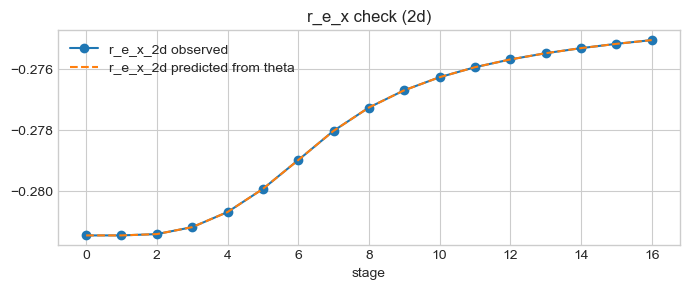

3d: MAE(obs vs rotated-pred) = 2.353969e-02


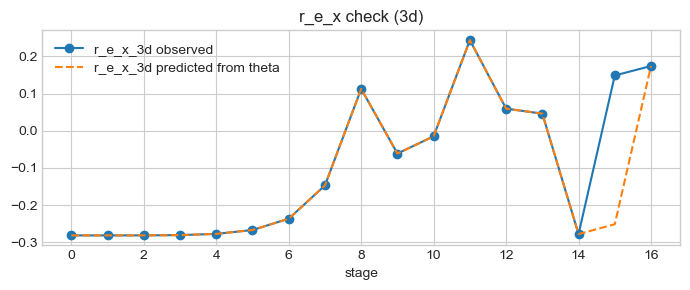

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# use first stage as body-frame reference approximation
rx0 = float(df.loc[df["stage"] == 0, "r_e_x_2d"].iloc[0])
rz0 = float(df.loc[df["stage"] == 0, "r_e_z_2d"].iloc[0]) if "r_e_z_2d" in df.columns else 0.0

for mode in ["2d", "3d"]:
    th = pd.to_numeric(df[f"theta_{mode}"], errors="coerce").to_numpy()
    rx_obs = pd.to_numeric(df[f"r_e_x_{mode}"], errors="coerce").to_numpy()
    # world x projection from body arm [rx0, rz0] rotated by theta
    rx_pred = rx0 * np.cos(th) - rz0 * np.sin(th)

    m = np.isfinite(rx_obs) & np.isfinite(rx_pred)
    mae = np.mean(np.abs(rx_obs[m] - rx_pred[m])) if np.any(m) else np.nan
    print(f"{mode}: MAE(obs vs rotated-pred) = {mae:.6e}")

    plt.figure(figsize=(7,3))
    plt.plot(df["stage"], rx_obs, "o-", label=f"r_e_x_{mode} observed")
    plt.plot(df["stage"], rx_pred, "--", label=f"r_e_x_{mode} predicted from theta")
    plt.title(f"r_e_x check ({mode})")
    plt.xlabel("stage")
    plt.legend()
    plt.tight_layout()
    plt.show()

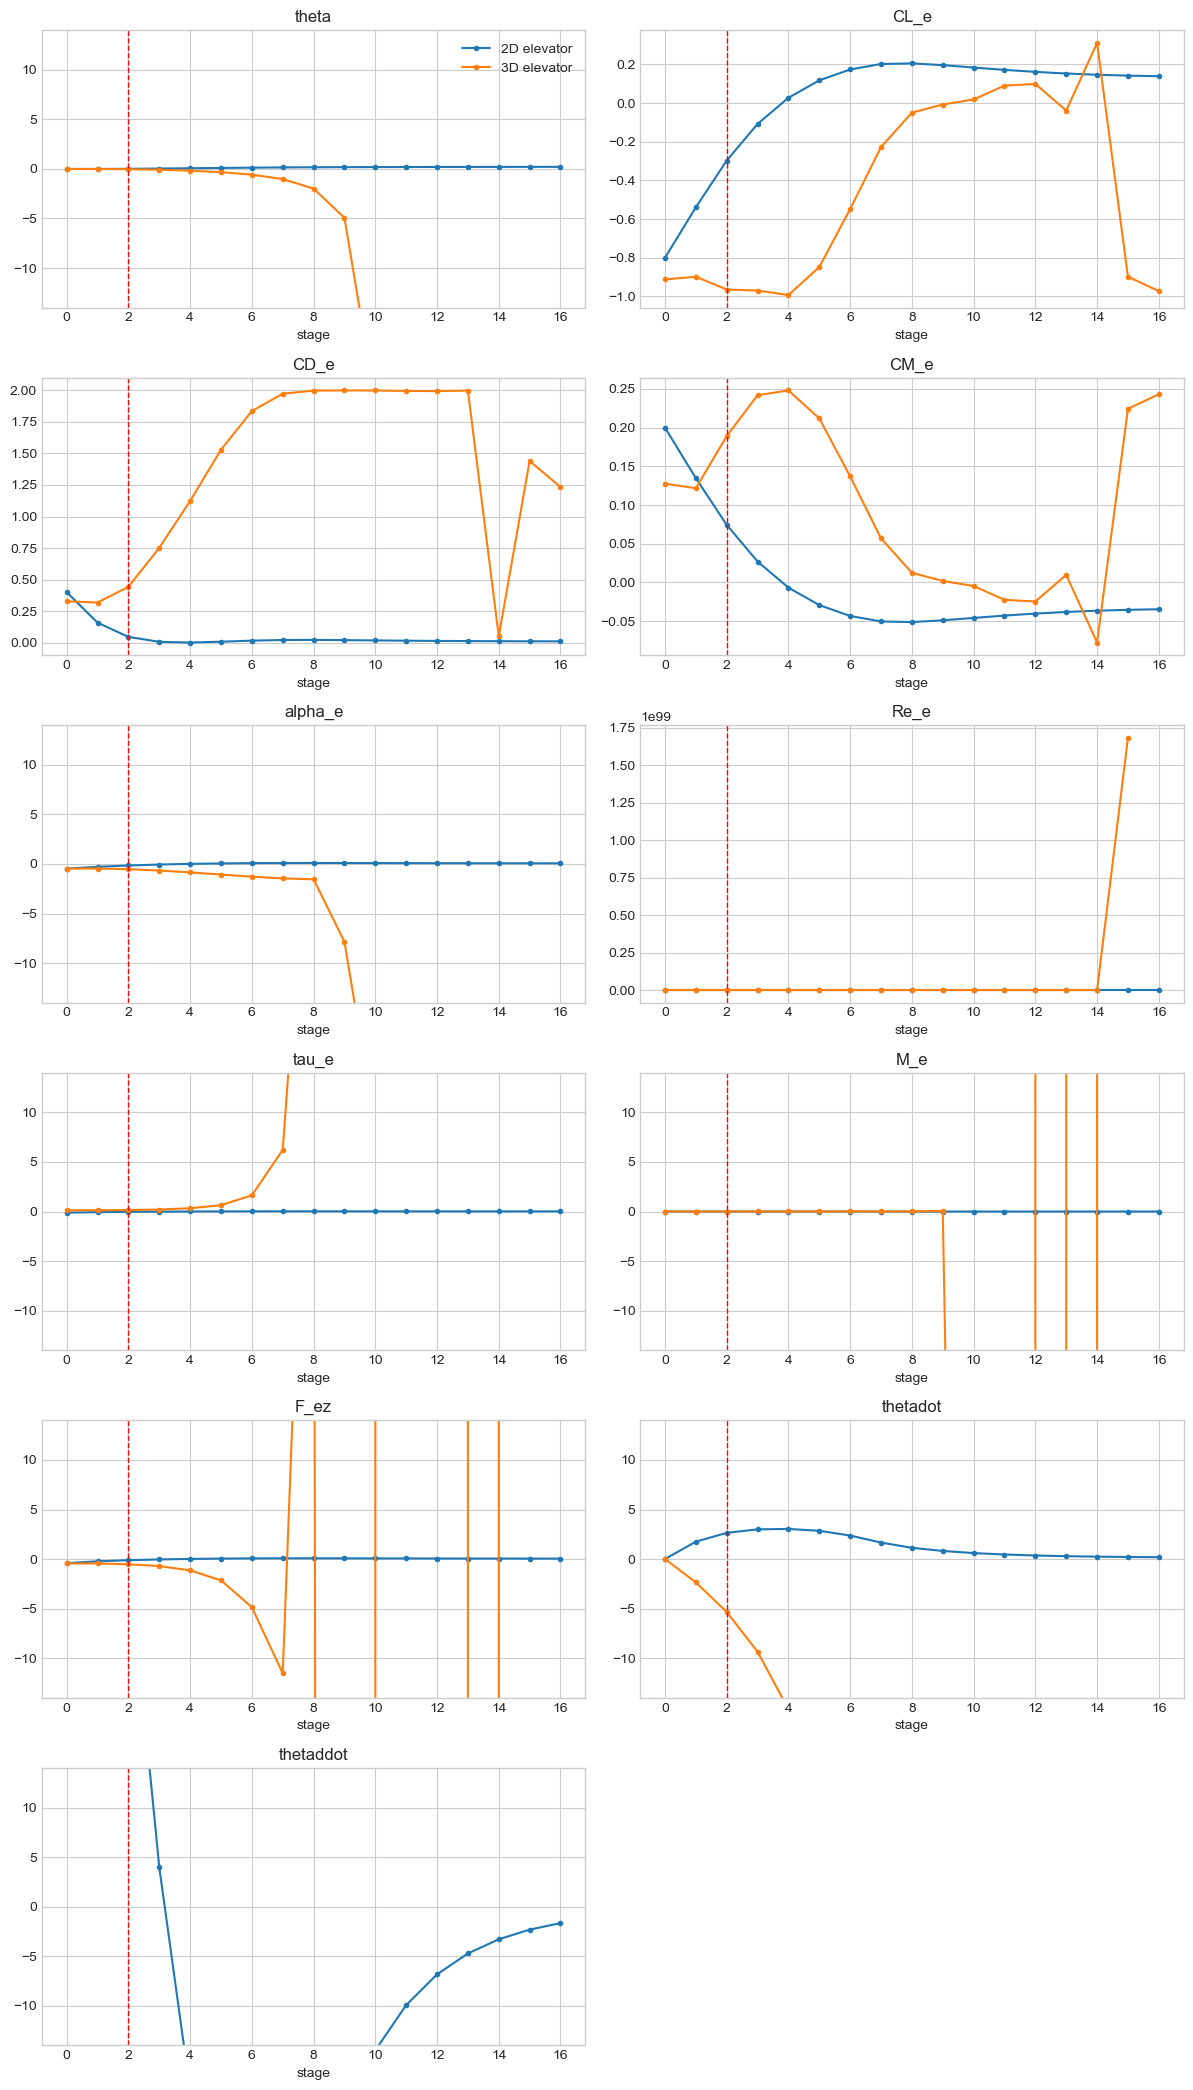

In [82]:
# Stage traces with capped scale for close-value diagnostics
plot_vars = ['theta', 'CL_e', 'CD_e', 'CM_e', 'alpha_e', 'Re_e', 'tau_e', 'M_e', 'F_ez', 'thetadot', 'thetaddot']
available = [v for v in plot_vars if f'{v}_2d' in df.columns and f'{v}_3d' in df.columns]
missing = sorted(set(plot_vars) - set(available))
if missing:
    print('Missing (skipped):', missing)

n = len(available)
cols = 2
rows = int(np.ceil(n / cols)) if n else 1
fig, axs = plt.subplots(rows, cols, figsize=(12, 3.5 * rows), squeeze=False)
axs = axs.ravel()

# Cap to ±14 for variables where overshoot hides early-stage behavior
cap_vars = {'theta', 'alpha_e', 'thetadot', 'thetaddot', 'tau_e', 'M_e', 'F_ez'}

for i, v in enumerate(available):
    ax = axs[i]
    y2 = pd.to_numeric(df[f'{v}_2d'], errors='coerce')
    y3 = pd.to_numeric(df[f'{v}_3d'], errors='coerce')

    ax.plot(df['stage'], y2, '-o', ms=3, label='2D elevator')
    ax.plot(df['stage'], y3, '-o', ms=3, label='3D elevator')
    if div_stage is not None:
        ax.axvline(div_stage, color='red', ls='--', lw=1)

    if v in cap_vars:
        ax.set_ylim(-14, 14)

    ax.set_title(v)
    ax.set_xlabel('stage')

for j in range(i + 1, len(axs)):
    axs[j].axis('off')

if len(available) > 0:
    axs[0].legend(loc='best')
plt.tight_layout()
plt.show()

In [83]:
# Interactive 3D curves: (alpha_e, Re_e, coeff) using Plotly
def has_cols(names):
    return all(n in df.columns for n in names)

def finite_triplet(a, b, c, clip_abs=None):
    a = pd.to_numeric(a, errors='coerce')
    b = pd.to_numeric(b, errors='coerce')
    c = pd.to_numeric(c, errors='coerce')
    m = np.isfinite(a) & np.isfinite(b) & np.isfinite(c)
    if clip_abs is not None:
        m = m & (np.abs(a) <= clip_abs) & (np.abs(b) <= clip_abs) & (np.abs(c) <= clip_abs)
    return a[m], b[m], c[m], m

pairs = [
    ('CL_e', ['alpha_e_2d','Re_e_2d','CL_e_2d','alpha_e_3d','Re_e_3d','CL_e_3d']),
    ('CD_e', ['alpha_e_2d','Re_e_2d','CD_e_2d','alpha_e_3d','Re_e_3d','CD_e_3d']),
]

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=('CL_e trajectory', 'CD_e trajectory')
)

col_idx = 1
for coeff, req in pairs:
    if not has_cols(req):
        print(f'Skipping {coeff} interactive 3D plot (missing columns).')
        continue

    a2, r2, c2, _ = finite_triplet(df['alpha_e_2d'], df['Re_e_2d'], df[f'{coeff}_2d'], clip_abs=1e12)
    a3, r3, c3, m3 = finite_triplet(df['alpha_e_3d'], df['Re_e_3d'], df[f'{coeff}_3d'], clip_abs=1e12)

    fig.add_trace(
        go.Scatter3d(
            x=a2, y=r2, z=c2, mode='lines+markers', name=f'2D elevator ({coeff})',
            marker=dict(size=4), line=dict(width=3)
        ),
        row=1, col=col_idx
    )
    fig.add_trace(
        go.Scatter3d(
            x=a3, y=r3, z=c3, mode='lines+markers', name=f'3D elevator ({coeff})',
            marker=dict(size=4), line=dict(width=3)
        ),
        row=1, col=col_idx
    )

    if div_stage is not None and div_stage in set(df['stage'].tolist()):
        rr = df[df['stage'] == div_stage].iloc[0]
        xk, yk, zk = rr.get('alpha_e_3d', np.nan), rr.get('Re_e_3d', np.nan), rr.get(f'{coeff}_3d', np.nan)
        if np.isfinite(xk) and np.isfinite(yk) and np.isfinite(zk):
            fig.add_trace(
                go.Scatter3d(
                    x=[xk], y=[yk], z=[zk], mode='markers',
                    marker=dict(size=7, symbol='x', color='red'),
                    name=f'div stage ({coeff})'
                ),
                row=1, col=col_idx
            )

    col_idx += 1

fig.update_layout(
    height=600, width=1200,
    title='Interactive 3D trajectories: elevator 2D vs 3D',
    scene=dict(xaxis_title='alpha_e [rad]', yaxis_title='Re_e', zaxis_title='CL_e'),
    scene2=dict(xaxis_title='alpha_e [rad]', yaxis_title='Re_e', zaxis_title='CD_e'),
    legend=dict(orientation='h')
)
fig.show()

In [84]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Optional smooth surface interpolation
try:
    from scipy.interpolate import griddata
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

def _finite_xyz(x, y, z, clip=1e12):
    x = pd.to_numeric(x, errors="coerce").to_numpy()
    y = pd.to_numeric(y, errors="coerce").to_numpy()
    z = pd.to_numeric(z, errors="coerce").to_numpy()
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    m &= (np.abs(x) <= clip) & (np.abs(y) <= clip) & (np.abs(z) <= clip)
    return x[m], y[m], z[m]

pairs = ["CL_e", "CD_e"]
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("CL_e: 2D vs 3D", "CD_e: 2D vs 3D")
)

for j, coeff in enumerate(pairs, start=1):
    x2, y2, z2 = _finite_xyz(df["alpha_e_2d"], df["Re_e_2d"], df[f"{coeff}_2d"])
    x3, y3, z3 = _finite_xyz(df["alpha_e_3d"], df["Re_e_3d"], df[f"{coeff}_3d"])

    # Trajectories
    fig.add_trace(go.Scatter3d(
        x=x2, y=y2, z=z2, mode="lines+markers",
        name=f"2D {coeff}", marker=dict(size=4), line=dict(width=4)
    ), row=1, col=j)

    fig.add_trace(go.Scatter3d(
        x=x3, y=y3, z=z3, mode="lines+markers",
        name=f"3D {coeff}", marker=dict(size=4), line=dict(width=4)
    ), row=1, col=j)

    # Optional smooth surfaces (from trajectory points; approximate)
    if HAVE_SCIPY and len(x2) >= 6 and len(x3) >= 6:
        xa = np.linspace(np.nanmin(np.r_[x2, x3]), np.nanmax(np.r_[x2, x3]), 40)
        ya = np.linspace(np.nanmin(np.r_[y2, y3]), np.nanmax(np.r_[y2, y3]), 40)
        XX, YY = np.meshgrid(xa, ya)

        Z2 = griddata(np.c_[x2, y2], z2, (XX, YY), method="linear")
        Z3 = griddata(np.c_[x3, y3], z3, (XX, YY), method="linear")

        fig.add_trace(go.Surface(
            x=XX, y=YY, z=Z2, opacity=0.35, showscale=False,
            name=f"2D {coeff} surface"
        ), row=1, col=j)

        fig.add_trace(go.Surface(
            x=XX, y=YY, z=Z3, opacity=0.35, showscale=False,
            name=f"3D {coeff} surface"
        ), row=1, col=j)

# Mark divergence point if available
if "div_stage" in globals() and div_stage is not None and div_stage in set(df["stage"].tolist()):
    rr = df[df["stage"] == div_stage].iloc[0]
    for j, coeff in enumerate(pairs, start=1):
        xk = rr.get("alpha_e_3d", np.nan)
        yk = rr.get("Re_e_3d", np.nan)
        zk = rr.get(f"{coeff}_3d", np.nan)
        if np.isfinite(xk) and np.isfinite(yk) and np.isfinite(zk):
            fig.add_trace(go.Scatter3d(
                x=[xk], y=[yk], z=[zk], mode="markers",
                marker=dict(size=8, color="red", symbol="x"),
                name=f"div stage ({coeff})"
            ), row=1, col=j)

fig.update_layout(
    height=650, width=1250,
    title="Elevator coefficient trajectories (and optional interpolated surfaces)",
    scene=dict(xaxis_title="alpha_e [rad]", yaxis_title="Re_e", zaxis_title="CL_e"),
    scene2=dict(xaxis_title="alpha_e [rad]", yaxis_title="Re_e", zaxis_title="CD_e"),
    legend=dict(orientation="h")
)
fig.show()

if not HAVE_SCIPY:
    print("SciPy not available: showing trajectories only (no interpolated surfaces).")

## Root-cause diagnostics (what diverges first, and why)

This section pinpoints the first strong divergence stage for each key signal and reconstructs the causal chain:

1. `alpha_e, Re_e` drift
2. `CL_e, CD_e, CM_e` split
3. `F_e, M_e` split
4. `tau_e` split
5. `thetaddot -> thetadot -> theta` runaway

It also compares `CM_e` and lever-arm terms (`r_e_x, r_e_z`) in early stages and full rollout, and checks if large `theta` radians are due to wrap issues or physical runaway.

In [85]:
import numpy as np
import pandas as pd

# ---------- helpers ----------
def _finite_pair(a, b):
    a = pd.to_numeric(a, errors='coerce')
    b = pd.to_numeric(b, errors='coerce')
    m = np.isfinite(a) & np.isfinite(b)
    return a[m], b[m], m

def _first_div_stage(df, var, abs_thr=None, rel_thr=None, eps=1e-12):
    c2, c3 = f"{var}_2d", f"{var}_3d"
    if c2 not in df.columns or c3 not in df.columns:
        return None, f"missing ({c2}/{c3})"

    a = pd.to_numeric(df[c2], errors='coerce').to_numpy()
    b = pd.to_numeric(df[c3], errors='coerce').to_numpy()
    s = df['stage'].to_numpy()

    for i in range(len(df)):
        if not (np.isfinite(a[i]) and np.isfinite(b[i])):
            return int(s[i]), "non-finite"
        da = abs(b[i] - a[i])
        ra = da / max(abs(a[i]), eps)
        hit_abs = (abs_thr is not None and da > abs_thr)
        hit_rel = (rel_thr is not None and ra > rel_thr)
        if hit_abs or hit_rel:
            why = []
            if hit_abs: why.append(f"|Δ|>{abs_thr}")
            if hit_rel: why.append(f"rel>{rel_thr}")
            return int(s[i]), ", ".join(why)
    return None, "no threshold hit"

def _ratio(b, a, eps=1e-12):
    if not (np.isfinite(a) and np.isfinite(b)):
        return np.nan
    return b / (a if abs(a) > eps else np.nan)

# ---------- 1) first divergence map ----------
thresholds = {
    'alpha_e': dict(abs_thr=np.deg2rad(5), rel_thr=3.0),
    'Re_e': dict(abs_thr=1000, rel_thr=3.0),
    'CL_e': dict(abs_thr=0.15, rel_thr=3.0),
    'CD_e': dict(abs_thr=0.2, rel_thr=3.0),
    'CM_e': dict(abs_thr=0.05, rel_thr=3.0),
    'M_e': dict(abs_thr=5e-4, rel_thr=3.0),
    'tau_e': dict(abs_thr=0.02, rel_thr=5.0),
    'thetaddot': dict(abs_thr=20, rel_thr=5.0),
    'thetadot': dict(abs_thr=5, rel_thr=5.0),
    'theta': dict(abs_thr=np.deg2rad(20), rel_thr=5.0),
}

rows = []
for v, th in thresholds.items():
    stg, why = _first_div_stage(df, v, **th)
    rows.append({'signal': v, 'first_div_stage': stg, 'criterion': why})

div_map = pd.DataFrame(rows).sort_values(['first_div_stage', 'signal'], na_position='last').reset_index(drop=True)
print('First strong divergence by signal:')
display(div_map)

# ---------- 2) causal-chain table around first event ----------
valid_stages = [x for x in div_map['first_div_stage'].tolist() if pd.notna(x)]
s0 = int(min(valid_stages)) if valid_stages else int(df['stage'].min())
window = df[(df['stage'] >= max(df['stage'].min(), s0-2)) & (df['stage'] <= min(df['stage'].max(), s0+6))].copy()

chain_vars = ['alpha_e','Re_e','CL_e','CD_e','CM_e','F_ex','F_ez','M_e','tau_e','thetaddot','thetadot','theta']
for v in chain_vars:
    c2, c3 = f'{v}_2d', f'{v}_3d'
    if c2 in window.columns and c3 in window.columns:
        window[f'{v}_delta'] = window[c3] - window[c2]
        window[f'{v}_ratio_3d_over_2d'] = [
            _ratio(b, a) for a,b in zip(window[c2].to_numpy(), window[c3].to_numpy())
        ]

show_cols = ['stage']
for v in ['alpha_e','Re_e','CM_e','M_e','tau_e','thetaddot','thetadot','theta']:
    for k in [f'{v}_2d', f'{v}_3d', f'{v}_delta', f'{v}_ratio_3d_over_2d']:
        if k in window.columns:
            show_cols.append(k)

print(f'Causal-chain window around first event (stage {s0}):')
display(window[show_cols])

# ---------- 3) CM_e + lever-arm comparators ----------
cm_cols = [c for c in [
    'stage',
    'CM_e_2d','CM_e_3d','M_e_2d','M_e_3d','q_e_2d','q_e_3d',
    'r_e_x_2d','r_e_x_3d','r_e_z_2d','r_e_z_3d',
    'tau_e_term_rxfz_2d','tau_e_term_rxfz_3d',
    'tau_e_term_rzfx_2d','tau_e_term_rzfx_3d',
    'tau_e_term_M_2d','tau_e_term_M_3d',
    'tau_e_2d','tau_e_3d'
] if c in df.columns]

early = df[df['stage'] <= 7][cm_cols].copy()
late  = df[df['stage'] >= 8][cm_cols].copy()

print('CM/lever table (early stable-ish stages <=7):')
display(early)

print('CM/lever table (later stages >=8):')
display(late)

summary_cm = pd.DataFrame({
    'metric': ['CM_e mean (<=7)','CM_e mean (>=8)','|r_e_x| mean (<=7)','|r_e_x| mean (>=8)','|r_e_z| mean (<=7)','|r_e_z| mean (>=8)'],
    '2d': [
        early['CM_e_2d'].mean() if 'CM_e_2d' in early else np.nan,
        late['CM_e_2d'].mean() if 'CM_e_2d' in late else np.nan,
        np.abs(early['r_e_x_2d']).mean() if 'r_e_x_2d' in early else np.nan,
        np.abs(late['r_e_x_2d']).mean() if 'r_e_x_2d' in late else np.nan,
        np.abs(early['r_e_z_2d']).mean() if 'r_e_z_2d' in early else np.nan,
        np.abs(late['r_e_z_2d']).mean() if 'r_e_z_2d' in late else np.nan,
    ],
    '3d': [
        early['CM_e_3d'].mean() if 'CM_e_3d' in early else np.nan,
        late['CM_e_3d'].mean() if 'CM_e_3d' in late else np.nan,
        np.abs(early['r_e_x_3d']).mean() if 'r_e_x_3d' in early else np.nan,
        np.abs(late['r_e_x_3d']).mean() if 'r_e_x_3d' in late else np.nan,
        np.abs(early['r_e_z_3d']).mean() if 'r_e_z_3d' in early else np.nan,
        np.abs(late['r_e_z_3d']).mean() if 'r_e_z_3d' in late else np.nan,
    ]
})
summary_cm['delta(3d-2d)'] = summary_cm['3d'] - summary_cm['2d']
print('CM/lever summary:')
display(summary_cm)

# ---------- 4) angle-wrap sanity check ----------
# Trig should be periodic: large theta in radians is not itself a math bug for sin/cos.
# But huge theta indicates dynamics runaway. This check quantifies when theta exceeds one turn.
turns = pd.DataFrame({'stage': df['stage']})
if 'theta_3d' in df.columns:
    t3 = pd.to_numeric(df['theta_3d'], errors='coerce').to_numpy()
    turns['theta_3d_rad'] = t3
    turns['theta_3d_deg'] = np.degrees(t3)
    for n in [1, 2, 5, 10]:
        thr = n * 2*np.pi
        idx = np.where(np.abs(t3) > thr)[0]
        turns[f'first_stage_|theta_3d|>{n}turn'] = int(df.iloc[idx[0]]['stage']) if len(idx) else np.nan

print('Angle growth checkpoints (3D):')
display(turns.head(1)[[c for c in turns.columns if c.startswith('first_stage_')]])

# ---------- 5) concise root-cause text ----------
print('Root-cause interpretation:')
print('- If CM_e splits first (before large lever-arm changes), aero moment model mismatch is primary.')
print('- If lever terms stay close early but tau_e/thetaddot split, instability is torque amplification, not geometry mismatch.')
print('- Large theta radians are consequence of runaway integration/torque, not a need to wrap angles for trig per se.')

First strong divergence by signal:


,signal,first_div_stage,criterion
0,CM_e,0,|Δ|>0.05
1,tau_e,0,|Δ|>0.02
2,thetaddot,0,|Δ|>20
3,CL_e,1,|Δ|>0.15
4,alpha_e,1,|Δ|>0.08726646259971647
5,CD_e,2,"|Δ|>0.2, rel>3.0"
6,M_e,2,|Δ|>0.0005
7,thetadot,2,|Δ|>5
8,Re_e,4,|Δ|>1000
9,theta,5,|Δ|>0.3490658503988659


Causal-chain window around first event (stage 0):


,stage,alpha_e_2d,alpha_e_3d,alpha_e_delta,alpha_e_ratio_3d_over_2d,Re_e_2d,Re_e_3d,Re_e_delta,Re_e_ratio_3d_over_2d,CM_e_2d,...,thetaddot_delta,thetaddot_ratio_3d_over_2d,thetadot_2d,thetadot_3d,thetadot_delta,thetadot_ratio_3d_over_2d,theta_2d,theta_3d,theta_delta,theta_ratio_3d_over_2d
0,0,-0.463648,-0.463648,0.000000,1.000000,4593.376086,4593.376086,0.000000,1.000000,0.200000,...,-411.280790,-1.344973,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,NaN
1,1,-0.284553,-0.454687,-0.170133,1.597895,4323.066410,4624.800738,301.734328,1.069796,0.134720,...,-387.480919,-3.374134,1.753883,-2.358925,-4.112808,-1.344973,0.000000,0.000000,0.000000,NaN
2,2,-0.150977,-0.526303,-0.375326,3.485987,4210.750345,4765.338300,554.587955,1.131708,0.074346,...,-437.644858,-11.238321,2.639729,-5.347888,-7.987617,-2.025923,0.017539,-0.023589,-0.041128,-1.344973
3,3,-0.054083,-0.660802,-0.606720,12.218326,4161.277825,5122.026012,960.748187,1.230878,0.026989,...,-585.478424,-146.345079,2.997331,-9.366735,-12.364066,-3.125025,0.043936,-0.077068,-0.121004,-1.754095
4,4,0.013609,-0.846859,-0.860468,-62.227557,4135.461360,5911.484303,1776.022943,1.429462,-0.006804,...,-965.634922,52.919521,3.037066,-15.181784,-18.218850,-4.998832,0.073909,-0.170735,-0.244645,-2.310063
5,5,0.058760,-1.064782,-1.123543,-18.120716,4114.832347,7654.701853,3539.869506,1.860271,-0.029313,...,-1932.321814,41.259112,2.851079,-25.024120,-27.875199,-8.777069,0.104280,-0.322553,-0.426833,-3.093144
6,6,0.087177,-1.280935,-1.368112,-14.693445,4094.817706,11663.884910,7569.067204,2.848450,-0.043368,...,-5070.043421,72.335726,2.371108,-44.827309,-47.198417,-18.905637,0.132791,-0.572795,-0.705585,-4.313508


CM/lever table (early stable-ish stages <=7):


...

CM/lever summary:


,metric,2d,3d,delta(3d-2d)
0,CM_e mean (<=7),0.038266,0.166799,0.128533
1,CM_e mean (>=8),-0.041572,0.040219,0.081791
2,|r_e_x| mean (<=7),0.280394,0.256604,-0.023791
3,|r_e_x| mean (>=8),0.275863,0.126643,-0.149220
4,|r_e_z| mean (<=7),0.018564,0.069736,0.051172
5,|r_e_z| mean (>=8),0.055738,0.223430,0.167692


Angle growth checkpoints (3D):


,first_stage_|theta_3d|>1turn,first_stage_|theta_3d|>2turn,first_stage_|theta_3d|>5turn,first_stage_|theta_3d|>10turn
0,10,10,11,11


Root-cause interpretation:
- If CM_e splits first (before large lever-arm changes), aero moment model mismatch is primary.
- If lever terms stay close early but tau_e/thetaddot split, instability is torque amplification, not geometry mismatch.
- Large theta radians are consequence of runaway integration/torque, not a need to wrap angles for trig per se.


In [86]:
# CM_e 3D interactive comparison on the same alpha/Re space (2D vs 3D overlaid)
import numpy as np
import pandas as pd
import plotly.graph_objects as go

try:
    from scipy.interpolate import griddata
    HAVE_SCIPY_CM = True
except Exception:
    HAVE_SCIPY_CM = False

def _finite_xyz_cm(x, y, z, clip=1e12):
    x = pd.to_numeric(x, errors='coerce').to_numpy()
    y = pd.to_numeric(y, errors='coerce').to_numpy()
    z = pd.to_numeric(z, errors='coerce').to_numpy()
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    m &= (np.abs(x) <= clip) & (np.abs(y) <= clip) & (np.abs(z) <= clip)
    return x[m], y[m], z[m]

req = ['alpha_e_2d','Re_e_2d','CM_e_2d','alpha_e_3d','Re_e_3d','CM_e_3d']
missing = [c for c in req if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns for CM plot: {missing}')

x2, y2, z2 = _finite_xyz_cm(df['alpha_e_2d'], df['Re_e_2d'], df['CM_e_2d'])
x3, y3, z3 = _finite_xyz_cm(df['alpha_e_3d'], df['Re_e_3d'], df['CM_e_3d'])

fig_cm = go.Figure()

# Overlaid trajectories
fig_cm.add_trace(go.Scatter3d(
    x=x2, y=y2, z=z2, mode='lines+markers', name='2D CM_e trajectory',
    marker=dict(size=5, color='royalblue'), line=dict(width=4, color='royalblue')
))
fig_cm.add_trace(go.Scatter3d(
    x=x3, y=y3, z=z3, mode='lines+markers', name='3D CM_e trajectory',
    marker=dict(size=5, color='darkorange'), line=dict(width=4, color='darkorange')
))

# Optional overlaid surfaces (same graph)
if HAVE_SCIPY_CM and len(x2) >= 6 and len(x3) >= 6:
    xa = np.linspace(np.nanmin(np.r_[x2, x3]), np.nanmax(np.r_[x2, x3]), 45)
    ya = np.linspace(np.nanmin(np.r_[y2, y3]), np.nanmax(np.r_[y2, y3]), 45)
    XX, YY = np.meshgrid(xa, ya)

    Z2 = griddata(np.c_[x2, y2], z2, (XX, YY), method='linear')
    Z3 = griddata(np.c_[x3, y3], z3, (XX, YY), method='linear')

    fig_cm.add_trace(go.Surface(
        x=XX, y=YY, z=Z2, opacity=0.30, showscale=False,
        colorscale='Blues', name='2D CM_e surface'
    ))
    fig_cm.add_trace(go.Surface(
        x=XX, y=YY, z=Z3, opacity=0.30, showscale=False,
        colorscale='Oranges', name='3D CM_e surface'
    ))

# Mark first divergence point on 3D branch
if 'div_stage' in globals() and div_stage is not None and div_stage in set(df['stage'].tolist()):
    rr = df[df['stage'] == div_stage].iloc[0]
    xk, yk, zk = rr.get('alpha_e_3d', np.nan), rr.get('Re_e_3d', np.nan), rr.get('CM_e_3d', np.nan)
    if np.isfinite(xk) and np.isfinite(yk) and np.isfinite(zk):
        fig_cm.add_trace(go.Scatter3d(
            x=[xk], y=[yk], z=[zk], mode='markers',
            marker=dict(size=8, symbol='x', color='red'),
            name='div stage (CM_e, 3D)'
        ))

fig_cm.update_layout(
    title='CM_e over alpha_e/Re_e (2D vs 3D overlaid)',
    height=700, width=1000,
    legend=dict(orientation='h'),
    scene=dict(
        xaxis_title='alpha_e [rad]',
        yaxis_title='Re_e',
        zaxis_title='CM_e'
    )
)
fig_cm.show()

if not HAVE_SCIPY_CM:
    print('SciPy not available: plotted trajectories only (no interpolated surfaces).')

In [87]:
# CM_e surfaces over the FULL sampled alpha/Re grid (not trajectories)
import numpy as np
import plotly.graph_objects as go
from pathlib import Path

art_dir = root / 'artifacts/3d_llt_export/Output_wing_elevator'
alpha_path = art_dir / 'sampling_alpha_grid.npy'
re_path = art_dir / 'sampling_Re_grid.npy'
cm3d_path = art_dir / 'elevator_raw_CM.npy'

for p in [alpha_path, re_path, cm3d_path]:
    if not p.exists():
        raise FileNotFoundError(f'Missing artifact file: {p}')

alpha_flat = np.load(alpha_path).reshape(-1)
re_flat = np.load(re_path).reshape(-1)
cm3d_flat = np.load(cm3d_path).reshape(-1)

# Build consistent alpha/Re mesh from sampled points
alpha_u = np.unique(alpha_flat)
re_u = np.unique(re_flat)
AA, RR = np.meshgrid(alpha_u, re_u)

# 3D CM from artifact values on sampled grid
cm3d_df = pd.DataFrame({'alpha': alpha_flat, 'Re': re_flat, 'CM3D': cm3d_flat})
cm3d_grid = (
    cm3d_df
    .pivot_table(index='Re', columns='alpha', values='CM3D', aggfunc='mean')
    .reindex(index=re_u, columns=alpha_u)
    .to_numpy()
)

# 2D CM model used in dynamics code: C_M(alpha) = -0.25 * C_L(alpha), C_L(alpha)=sin(2*alpha)
# alpha in artifacts is in degrees -> convert to radians.
AA_rad = np.deg2rad(AA)
cm2d_grid = -0.25 * (2.0 * np.sin(AA_rad) * np.cos(AA_rad))

fig = go.Figure()
fig.add_trace(go.Surface(
    x=AA, y=RR, z=cm2d_grid,
    name='CM_e 2D model surface',
    opacity=0.55,
    colorscale='Blues',
    showscale=False
))
fig.add_trace(go.Surface(
    x=AA, y=RR, z=cm3d_grid,
    name='CM_e 3D LLT surface',
    opacity=0.55,
    colorscale='Oranges',
    showscale=False
))

# Optional difference surface can help spotting discrepancy quickly
cm_diff = cm3d_grid - cm2d_grid
fig.add_trace(go.Surface(
    x=AA, y=RR, z=cm_diff,
    name='CM_e (3D - 2D) surface',
    opacity=0.35,
    colorscale='RdBu',
    visible='legendonly',
    showscale=False
))

fig.update_layout(
    title='CM_e surfaces over full sampled alpha/Re range (2D vs 3D)',
    height=760, width=1100,
    legend=dict(orientation='h'),
    scene=dict(
        xaxis_title='alpha [deg]',
        yaxis_title='Re',
        zaxis_title='CM_e'
    )
)
fig.show()

print('Grid shape:', AA.shape, '| alpha range [deg]:', (float(alpha_u.min()), float(alpha_u.max())), '| Re range:', (float(re_u.min()), float(re_u.max())))
print('CM 2D range:', (float(np.nanmin(cm2d_grid)), float(np.nanmax(cm2d_grid))))
print('CM 3D range:', (float(np.nanmin(cm3d_grid)), float(np.nanmax(cm3d_grid))))
print('CM diff range (3D-2D):', (float(np.nanmin(cm_diff)), float(np.nanmax(cm_diff))))

Grid shape: (32, 32) | alpha range [deg]: (-29.963863372802734, 29.963863372802734) | Re range: (160.16696166992188, 99939.8359375)
CM 2D range: (-0.21634849905967712, 0.21634849905967712)
CM 3D range: (-0.1568891406059265, 0.1568891406059265)
CM diff range (3D-2D): (-0.15178896486759186, 0.15178896486759186)


In [88]:
import numpy as np
import pandas as pd
import yaml
from pathlib import Path

def _to_num(s):
    return pd.to_numeric(s, errors="coerce")

def body_arm_from_world(df, mode):
    # world -> body inverse rotation using theta
    th = _to_num(df[f"theta_{mode}"]).to_numpy()
    rx = _to_num(df[f"r_e_x_{mode}"]).to_numpy()
    rz = _to_num(df[f"r_e_z_{mode}"]).to_numpy() if f"r_e_z_{mode}" in df.columns else np.zeros_like(rx)

    m = np.isfinite(th) & np.isfinite(rx) & np.isfinite(rz)
    rb_x = np.full_like(rx, np.nan, dtype=float)
    rb_z = np.full_like(rz, np.nan, dtype=float)

    # inverse of world rotation
    rb_x[m] = rx[m] * np.cos(th[m]) + rz[m] * np.sin(th[m])
    rb_z[m] = -rx[m] * np.sin(th[m]) + rz[m] * np.cos(th[m])

    out = pd.DataFrame({
        "stage": df["stage"].to_numpy(),
        f"rb_x_{mode}": rb_x,
        f"rb_z_{mode}": rb_z
    })
    return out

# 1) Geometric lever point (body frame) in both sims
b2 = body_arm_from_world(df, "2d")
b3 = body_arm_from_world(df, "3d")
bb = b2.merge(b3, on="stage")

print("Body-frame lever estimate (first rows):")
display(bb.head(8))

print("Body-frame lever stats (early stages <=7):")
early = bb[bb["stage"] <= 7]
stats = pd.DataFrame([
    {
        "mode":"2d",
        "rb_x_mean": np.nanmean(early["rb_x_2d"]),
        "rb_x_std": np.nanstd(early["rb_x_2d"]),
        "rb_z_mean": np.nanmean(early["rb_z_2d"]),
        "rb_z_std": np.nanstd(early["rb_z_2d"]),
    },
    {
        "mode":"3d",
        "rb_x_mean": np.nanmean(early["rb_x_3d"]),
        "rb_x_std": np.nanstd(early["rb_x_3d"]),
        "rb_z_mean": np.nanmean(early["rb_z_3d"]),
        "rb_z_std": np.nanstd(early["rb_z_3d"]),
    }
])
display(stats)

# 2) Effective CM scaling length c_ref from rollout:
#    c_ref_eff = M_e / (q_e * S_e * CM_e)
#    (uses S_e from config if available)
S_e = np.nan
cfg_path = root / "conf/test.yaml"
if cfg_path.exists():
    cfg = yaml.safe_load(open(cfg_path, "r"))
    S_e = cfg.get("plane", {}).get("dyn", {}).get("S_e", np.nan)

def cref_eff(df, mode, S):
    req = [f"M_e_{mode}", f"q_e_{mode}", f"CM_e_{mode}"]
    if any(c not in df.columns for c in req) or not np.isfinite(S):
        return pd.Series(np.nan, index=df.index)
    M = _to_num(df[f"M_e_{mode}"])
    q = _to_num(df[f"q_e_{mode}"])
    CM = _to_num(df[f"CM_e_{mode}"])
    den = q * S * CM
    out = M / den.replace(0, np.nan)
    return out

df["c_ref_eff_2d"] = cref_eff(df, "2d", S_e)
df["c_ref_eff_3d"] = cref_eff(df, "3d", S_e)

print(f"S_e from config: {S_e}")
print("Effective c_ref stats (early <=7):")
ce = df[df["stage"] <= 7][["stage","c_ref_eff_2d","c_ref_eff_3d"]]
display(ce)
display(pd.DataFrame([{
    "c_ref_eff_2d_mean": np.nanmean(ce["c_ref_eff_2d"]),
    "c_ref_eff_3d_mean": np.nanmean(ce["c_ref_eff_3d"]),
    "delta": np.nanmean(ce["c_ref_eff_3d"]) - np.nanmean(ce["c_ref_eff_2d"]),
}]))

# 3) Raw CM side-by-side
cm_cols = [c for c in ["stage","alpha_e_2d","Re_e_2d","CM_e_2d","alpha_e_3d","Re_e_3d","CM_e_3d"] if c in df.columns]
print("CM_e side-by-side:")
display(df[cm_cols])

Body-frame lever estimate (first rows):


,stage,rb_x_2d,rb_z_2d,rb_x_3d,rb_z_3d
0,0,-0.281461,0.000000e+00,-0.281461,0.000000e+00
1,1,-0.281461,0.000000e+00,-0.281461,0.000000e+00
2,2,-0.281461,6.071532e-18,-0.281461,8.673617e-18
3,3,-0.281461,8.500145e-17,-0.281461,-1.387779e-17
4,4,-0.281461,-1.040834e-17,-0.281461,-6.938894e-18
5,5,-0.281461,0.000000e+00,-0.281461,-6.938894e-17
6,6,-0.281461,0.000000e+00,-0.281461,0.000000e+00
7,7,-0.281461,9.020562e-17,-0.281461,0.000000e+00


Body-frame lever stats (early stages <=7):


,mode,rb_x_mean,rb_x_std,rb_z_mean,rb_z_std
0,2d,-0.281461,3.925231e-17,2.135878e-17,3.849986e-17
1,3d,-0.281461,2.775558e-17,-1.019150e-17,2.318368e-17


S_e from config: 0.017
Effective c_ref stats (early <=7):


,stage,c_ref_eff_2d,c_ref_eff_3d
0,0,0.01,0.01
1,1,0.01,0.01
2,2,0.01,0.01
3,3,0.01,0.01
4,4,0.01,0.01
5,5,0.01,0.01
6,6,0.01,0.01
7,7,0.01,0.01


,c_ref_eff_2d_mean,c_ref_eff_3d_mean,delta
0,0.01,0.01,1.788500e-15


CM_e side-by-side:


,stage,alpha_e_2d,Re_e_2d,CM_e_2d,alpha_e_3d,Re_e_3d,CM_e_3d
0,0,-0.463648,4593.376086,0.200000,-4.636475e-01,4.593376e+03,0.127690
1,1,-0.284553,4323.066410,0.134720,-4.546865e-01,4.624801e+03,0.121667
2,2,-0.150977,4210.750345,0.074346,-5.263032e-01,4.765338e+03,0.189177
3,3,-0.054083,4161.277825,0.026989,-6.608025e-01,5.122026e+03,0.241933
4,4,0.013609,4135.461360,-0.006804,-8.468591e-01,5.911484e+03,0.248113
5,5,0.058760,4114.832347,-0.029313,-1.064782e+00,7.654702e+03,0.211977
6,6,0.087177,4094.817706,-0.043368,-1.280935e+00,1.166388e+04,0.136948
7,7,0.101583,4068.686887,-0.050443,-1.456022e+00,2.237839e+04,0.056884
8,8,0.103274,4033.071076,-0.051270,-1.546068e+00,6.270885e+04,0.012359
9,9,0.098628,3994.655328,-0.048995,-7.850183e+00,3.999296e+05,0.001899


In [89]:
# CM_e surfaces: ground truth vs Chebyshev fit (separate interactive 3D graphs for 2D and 3D)
import numpy as np
import yaml
import plotly.graph_objects as go
from pathlib import Path

art_dir = root / 'artifacts/3d_llt_export/Output_wing_elevator'
alpha_path = art_dir / 'sampling_alpha_grid.npy'
re_path = art_dir / 'sampling_Re_grid.npy'
cm3d_raw_path = art_dir / 'elevator_raw_CM.npy'
cm3d_phi_path = art_dir / 'elevator_cheby_phi_CM.npy'

for p in [alpha_path, re_path, cm3d_raw_path, cm3d_phi_path]:
    if not p.exists():
        raise FileNotFoundError(f'Missing artifact file: {p}')

alpha_flat = np.load(alpha_path).reshape(-1)  # degrees
re_flat = np.load(re_path).reshape(-1)
cm3d_raw_flat = np.load(cm3d_raw_path).reshape(-1)
phi3d = np.load(cm3d_phi_path).reshape(-1, 1)

# Get model settings used for reduced model fit when available
cfg_local = {}
for cand in [art_dir / 'test.yaml', root / 'conf/test.yaml']:
    if cand.exists():
        with open(cand, 'r') as f:
            cfg_local = yaml.safe_load(f) or {}
        break

nf = cfg_local.get('neuralFoilSampling', {}) if isinstance(cfg_local, dict) else {}
rm = cfg_local.get('reducedModel', {}) if isinstance(cfg_local, dict) else {}

aoa_min = float(nf.get('AoA_min', np.min(alpha_flat)))
aoa_max = float(nf.get('AoA_max', np.max(alpha_flat)))
re_min = float(nf.get('Re_min', np.min(re_flat)))
re_max = float(nf.get('Re_max', np.max(re_flat)))
l2_reg = float(rm.get('l2_reg', 0.5))

def scale_to_domain(x, min_val, max_val):
    return 2.0 * (x - min_val) / (max_val - min_val) - 1.0

def chebyshev_basis(alpha_scaled, re_scaled, deg):
    B = alpha_scaled.shape[0]
    T_a = np.zeros((B, deg + 1), dtype=float)
    T_r = np.zeros((B, deg + 1), dtype=float)
    T_a[:, 0] = 1.0
    T_r[:, 0] = 1.0
    if deg >= 1:
        T_a[:, 1] = alpha_scaled
        T_r[:, 1] = re_scaled
    for n in range(2, deg + 1):
        T_a[:, n] = 2.0 * alpha_scaled * T_a[:, n - 1] - T_a[:, n - 2]
        T_r[:, n] = 2.0 * re_scaled * T_r[:, n - 1] - T_r[:, n - 2]
    return (T_a[:, :, None] * T_r[:, None, :]).reshape(B, -1)

# Degree inferred from saved 3D coeff vector length
deg = int(round(np.sqrt(phi3d.shape[0]) - 1))
if (deg + 1) ** 2 != phi3d.shape[0]:
    raise ValueError(f'Invalid Chebyshev coeff count: {phi3d.shape[0]} (not a square)')

a_s = scale_to_domain(alpha_flat, aoa_min, aoa_max)
r_s = scale_to_domain(re_flat, re_min, re_max)
X = chebyshev_basis(a_s, r_s, deg)

# 3D: ground truth from LLT raw artifact vs saved Chebyshev fit
cm3d_fit_flat = (X @ phi3d).reshape(-1)

# 2D: ground truth from analytic model, then Chebyshev fit with same basis/reg as ReducedModel
alpha_rad_flat = np.deg2rad(alpha_flat)
cm2d_raw_flat = -0.25 * (2.0 * np.sin(alpha_rad_flat) * np.cos(alpha_rad_flat))
A = X.T @ X + l2_reg * np.eye(X.shape[1])
b = X.T @ cm2d_raw_flat.reshape(-1, 1)
phi2d = np.linalg.solve(A, b)
cm2d_fit_flat = (X @ phi2d).reshape(-1)

# reshape to mesh for surfaces
alpha_u = np.unique(alpha_flat)
re_u = np.unique(re_flat)
AA, RR = np.meshgrid(alpha_u, re_u)

def to_grid(a_flat, r_flat, z_flat, a_u, r_u):
    key = np.rec.fromarrays([r_flat, a_flat])
    order = np.argsort(key, kind='mergesort')
    rs = r_flat[order]
    aas = a_flat[order]
    zs = z_flat[order]
    # pivot via dict to avoid pandas dependency here
    out = np.full((len(r_u), len(a_u)), np.nan, dtype=float)
    a_index = {v: i for i, v in enumerate(a_u)}
    r_index = {v: i for i, v in enumerate(r_u)}
    for rv, av, zv in zip(rs, aas, zs):
        out[r_index[rv], a_index[av]] = zv
    return out

cm3d_raw = to_grid(alpha_flat, re_flat, cm3d_raw_flat, alpha_u, re_u)
cm3d_fit = to_grid(alpha_flat, re_flat, cm3d_fit_flat, alpha_u, re_u)
cm2d_raw = to_grid(alpha_flat, re_flat, cm2d_raw_flat, alpha_u, re_u)
cm2d_fit = to_grid(alpha_flat, re_flat, cm2d_fit_flat, alpha_u, re_u)

# ---------- Figure 1: 3D ----------
fig3d = go.Figure()
fig3d.add_trace(go.Surface(
    x=AA, y=RR, z=cm3d_raw, name='3D LLT CM_e (ground truth)',
    opacity=0.60, colorscale='Oranges', showscale=False
))
fig3d.add_trace(go.Surface(
    x=AA, y=RR, z=cm3d_fit, name='3D CM_e Chebyshev fit',
    opacity=0.60, colorscale='Blues', showscale=False
))
fig3d.add_trace(go.Surface(
    x=AA, y=RR, z=(cm3d_fit - cm3d_raw), name='3D fit error (fit-gt)',
    opacity=0.40, colorscale='RdBu', visible='legendonly', showscale=False
))
fig3d.update_layout(
    title=f'3D elevator CM_e: LLT ground truth vs Chebyshev fit (deg={deg})',
    height=760, width=1100, legend=dict(orientation='h'),
    scene=dict(xaxis_title='alpha [deg]', yaxis_title='Re', zaxis_title='CM_e')
)
fig3d.show()

# ---------- Figure 2: 2D ----------
fig2d = go.Figure()
fig2d.add_trace(go.Surface(
    x=AA, y=RR, z=cm2d_raw, name='2D analytic CM_e (ground truth)',
    opacity=0.60, colorscale='Oranges', showscale=False
))
fig2d.add_trace(go.Surface(
    x=AA, y=RR, z=cm2d_fit, name='2D CM_e Chebyshev fit',
    opacity=0.60, colorscale='Blues', showscale=False
))
fig2d.add_trace(go.Surface(
    x=AA, y=RR, z=(cm2d_fit - cm2d_raw), name='2D fit error (fit-gt)',
    opacity=0.40, colorscale='RdBu', visible='legendonly', showscale=False
))
fig2d.update_layout(
    title=f'2D elevator CM_e: analytic ground truth vs Chebyshev fit (deg={deg}, l2={l2_reg})',
    height=760, width=1100, legend=dict(orientation='h'),
    scene=dict(xaxis_title='alpha [deg]', yaxis_title='Re', zaxis_title='CM_e')
)
fig2d.show()

# quick fit metrics
mse3d = float(np.nanmean((cm3d_fit - cm3d_raw) ** 2))
mse2d = float(np.nanmean((cm2d_fit - cm2d_raw) ** 2))
print('Chebyshev degree:', deg, '| l2_reg (2D fit):', l2_reg)
print('3D fit MSE:', mse3d, '| max|err|:', float(np.nanmax(np.abs(cm3d_fit - cm3d_raw))))
print('2D fit MSE:', mse2d, '| max|err|:', float(np.nanmax(np.abs(cm2d_fit - cm2d_raw))))

Chebyshev degree: 25 | l2_reg (2D fit): 0.0
3D fit MSE: 8.726960682576991e-06 | max|err|: 0.01272660167347001
2D fit MSE: 3.12467068862609e-17 | max|err|: 1.0554463636403e-08
